# Sonification of Astronomical Images 
### Pre-downloaded data stored in numpy arrays. Pro Tools Synth
https://irsa.ipac.caltech.edu/data/SPHEREx/docs/overview_qr.html

https://astroquery.readthedocs.io/en/latest/ipac/irsa/irsa.html

This publication makes use of data products from the Spectro-Photometer for the History of the Universe, Epoch of Reionization and Ices Explorer (SPHEREx), which is a joint project of the Jet Propulsion Laboratory and the California Institute of Technology, and is funded by the National Aeronautics and Space Administration.

Hands on Astronomical Data Sonification, Adrián García Riber, SVO 2026

This research has made use of the Spanish Virtual Observatory (https://svo.cab.inta-csic.es) project funded by MCIN/AEI/10.13039/501100011033 through grant PID2023-146210NB-I00.

In [1]:
import cv2
import time
import rtmidi
import numpy as np
import matplotlib.pyplot as plt

# Sonification proposal
##### Bright <=> MIDI velocity
##### x-axis 128 pixels <=> 128 notes
##### y-axis Up-Down scanning 

In [2]:
#Function for the normalization of bright levels, fits them to match the 128 values of velocity in MIDI
def normalized_brights(brights, v_min, v_max, midi_min=0, midi_max=127):
    # Normalizes to 0-1
    normalized_brights = (brights - v_min) / (v_max - v_min)
    # Scales to MIDI range
    velocity_scaled = normalized_brights * (midi_max - midi_min) + midi_min
    # Rounds and converts to integers within MIDI range
    velocity_scaled = np.clip(np.round(velocity_scaled), midi_min, midi_max).astype(int)
    return velocity_scaled


In [3]:
Spitzer_Image = np.load('Spitzer_Image_1.npy')
brights = Spitzer_Image
v_min = np.min(brights)
v_max = np.max(brights)
normalized_brights = normalized_brights(brights, v_min, v_max)

In [4]:
normalized_brights[59]

array([ 29,  21,  26,  24,  25,  26,  26,  16,  15,  16,  19,  21,  10,
        17,  21,  21,  15,  12,  26,  24,  26,  22,  23,  38,  39,  93,
       121, 127,  81,  52,  41,  37,  14,  16,  25,  25,  28,  25,  21,
        22,  34,  25,  25,  26,  24,  21,  19,  25,  24,  26,  26,  19,
        21,  21,  20,  15,  11,  26,  36,  22,  17,  16,  16,  19,  28,
        18,  17,  19,  20,  20,  15,  21,  24,  30,  28,  21,  18,  14,
        10,   9,  13,  21,  24,  25,  19,  21,  15,  13,  21,  17,  24,
        26,  26,  31,  33,  23,  34,  31,  24,  16,  24,  19,  20,  30,
        29,  20,  15,  19,  20,  23,  20,  15,  20,  32,  23,  20,  24,
        25,  31,  32,  17,  11,  13,  19,  25,  23,  29,  29])

In [5]:
normalized_brights[59][27]

np.int64(127)

In [6]:
dim = len(normalized_brights)
dim

128

Row: 0
Row: 1
Row: 2
Row: 3
Row: 4
Row: 5
Row: 6
Row: 7
Row: 8
Row: 9
Row: 10
Row: 11
Row: 12
Row: 13
Row: 14
Row: 15
Row: 16
Row: 17
Row: 18
Row: 19
Row: 20
_________Note: 16
Row: 21
_________Note: 15
_________Note: 16
_________Note: 17
Row: 22
_________Note: 15
_________Note: 16
Row: 23
_________Note: 16
Row: 24
Row: 25
Row: 26
Row: 27
Row: 28
Row: 29
Row: 30
Row: 31
Row: 32
Row: 33
Row: 34
Row: 35
Row: 36
Row: 37
Row: 38
Row: 39
Row: 40
Row: 41
Row: 42
Row: 43
_________Note: 74
_________Note: 75
Row: 44
_________Note: 74
_________Note: 75
Row: 45
_________Note: 73
_________Note: 74
_________Note: 75
Row: 46
_________Note: 73
_________Note: 74
Row: 47
_________Note: 50
_________Note: 51
Row: 48
_________Note: 50
_________Note: 51
Row: 49
_________Note: 50
_________Note: 51
Row: 50
Row: 51
Row: 52
_________Note: 47
_________Note: 48
_________Note: 49
_________Note: 50
Row: 53
_________Note: 47
_________Note: 48
_________Note: 49
Row: 54
_________Note: 49
Row: 55
Row: 56
_________Note:

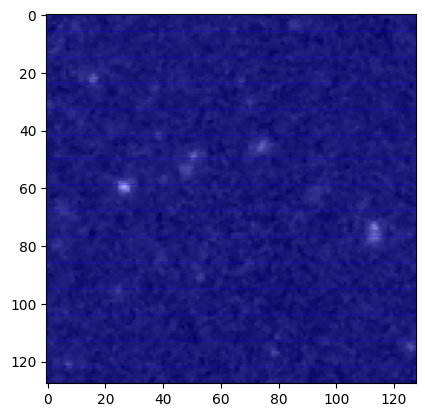

In [7]:
high_threshold = 50
low_threshold = 40

chords = []
amplitudes = []

midiout = rtmidi.MidiOut()
available_ports = midiout.get_ports()

if available_ports:
    midiout.open_port(0)  # Open first available port
else:
    midiout.open_virtual_port("Virtual Output")

# Creates a single persistent window before the loop
window_name = 'SPITZER Images'
cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
cv2.setWindowProperty(window_name, cv2.WND_PROP_TOPMOST, 1)

# Start with the image
plt.imshow(brights, cmap='grey', origin='upper')
plt.savefig('image.png')
img = cv2.imread("image.png")
cv2.imshow(window_name, img)
cv2.waitKey(1)


with midiout:
    for y in range(dim): #dim = y_dim = x_dim = 200 pixels
        #Image
        plt.axhline(y=y, color='blue', linewidth=2, alpha = 0.4)
        plt.savefig('image.png')
        #plt.close()
        for x in range(dim):
            note = x
            amplitude = int(normalized_brights[y][x])

            if normalized_brights[y][x] >= high_threshold: #Stars and Galaxies
                #Sound
                chords.append(x)
                amplitudes.append(amplitude)
                print ("_________Note:", x)

                #note on: channel (ch1=0x90)/ note / velocity
                note_on = [0x90, note, amplitude]
                #note_off = [0x80, note, amplitude]  # Note off on same channel/note
    
                midiout.send_message(note_on)
                #midiout.send_message(note_off)
            '''    
            if low_threshold < normalized_brights[y][x] < high_threshold:    #Faint objects

                #note on: channel (ch1=0x90)/ note / velocity
                note_on = [0x91, note, amplitude]
                #note_off = [0x81, note, amplitude]  # Note off on same channel/note
    
                midiout.send_message(note_on)
                #midiout.send_message(note_off)

            if  normalized_brights[y][x] < low_threshold:    #Background noise

                #note on: channel (ch1=0x90)/ note / velocity
                note_on = [0x92, note, amplitude]
                #note_off = [0x81, note, amplitude]  # Note off on same channel/note
    
                midiout.send_message(note_on)
                #midiout.send_message(note_off)
        '''
        img = cv2.imread("image.png")
        cv2.imshow(window_name, img)
                
        print ("Row:", y)
        time.sleep(.25)  
        # IMPORTANT: Process window events, small delay (1 ms)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    cv2.waitKey(1)
    for chord in chords:
        note_off = [0x80, chord, 0]  # Note off on same channel/note
        midiout.send_message(note_off)
